In [ ]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import cv2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import random
import shap
from utils import train_epoch, validate_epoch, test_model, conformal_prediction
from models import Autoencoder, ResNetBlock1D, TumorClassifierRes

In [ ]:
data_dir = "/binary_one_type_split"

image_size = 256

# Transforms
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Train/Test Datasets
full_train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform)


# Train/Test/Val/Calibration split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
test_size = int(0.6*len(test_dataset))
calibration_size = len(test_dataset) - test_size


g = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=g)
test_dataset, calibration_dataset = random_split(test_dataset, [test_size, calibration_size], generator=g)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False) # Shuffle False for val
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False) # Shuffle False for test
calibration_loader = DataLoader(calibration_dataset, batch_size=128, shuffle=False) # Shuffle False for calibration


print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Calibration dataset size: {len(calibration_dataset)}")

Training dataset size: 2416
Validation dataset size: 604
Test dataset size: 453
Calibration dataset size: 302


# ResNet Head Classifier Training and Test

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = Autoencoder(latent_dim=128)
model.load_state_dict(torch.load("content/autoencoder.pth"))
model.eval()

encoder = model.encoder

classifier_model = TumorClassifierRes(encoder, latent_dim=128).to(device)

# Setup
num_classes = 2
epochs = 50
batch_size = 128

Using device: cuda


In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(classifier_model.parameters(), lr=1e-4, weight_decay=1e-3)

best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0

# Training Loop
for epoch in range(epochs):
    train_loss, train_accuracy = train_epoch(classifier_model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate_epoch(classifier_model, val_loader, criterion, device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping at epoch {epoch+1}!")
            break

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"   Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
    print(f"   Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")


Epoch 1/50:
   Train Loss: 0.5487, Train Acc: 0.7409
   Val Loss: 0.4793, Val Acc: 0.8526
Epoch 2/50:
   Train Loss: 0.4317, Train Acc: 0.8506
   Val Loss: 0.3878, Val Acc: 0.8659
Epoch 3/50:
   Train Loss: 0.3379, Train Acc: 0.8994
   Val Loss: 0.3209, Val Acc: 0.9007
Epoch 4/50:
   Train Loss: 0.2700, Train Acc: 0.9342
   Val Loss: 0.2677, Val Acc: 0.9288
Epoch 5/50:
   Train Loss: 0.2285, Train Acc: 0.9383
   Val Loss: 0.2410, Val Acc: 0.9288
Epoch 6/50:
   Train Loss: 0.1918, Train Acc: 0.9512
   Val Loss: 0.2209, Val Acc: 0.9387
Epoch 7/50:
   Train Loss: 0.1678, Train Acc: 0.9615
   Val Loss: 0.1845, Val Acc: 0.9503
Epoch 8/50:
   Train Loss: 0.1401, Train Acc: 0.9706
   Val Loss: 0.1715, Val Acc: 0.9536
Epoch 9/50:
   Train Loss: 0.1240, Train Acc: 0.9760
   Val Loss: 0.1533, Val Acc: 0.9619
Epoch 10/50:
   Train Loss: 0.1001, Train Acc: 0.9851
   Val Loss: 0.1455, Val Acc: 0.9586
Epoch 11/50:
   Train Loss: 0.0903, Train Acc: 0.9876
   Val Loss: 0.1213, Val Acc: 0.9636
Epoch 12

In [ ]:
# Test Loop 
test_loss, test_accuracy, test_precision, test_recall, test_f1 = test_model(classifier_model, test_loader, criterion, device)
print(f"\nTest Results:")
print(f"   Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1-Score: {test_f1:.4f}")


Test Results:
   Test Loss: 0.0849, Test Accuracy: 0.9735, Test Precision: 0.9735, Test Recall: 0.9735, Test F1-Score: 0.9735


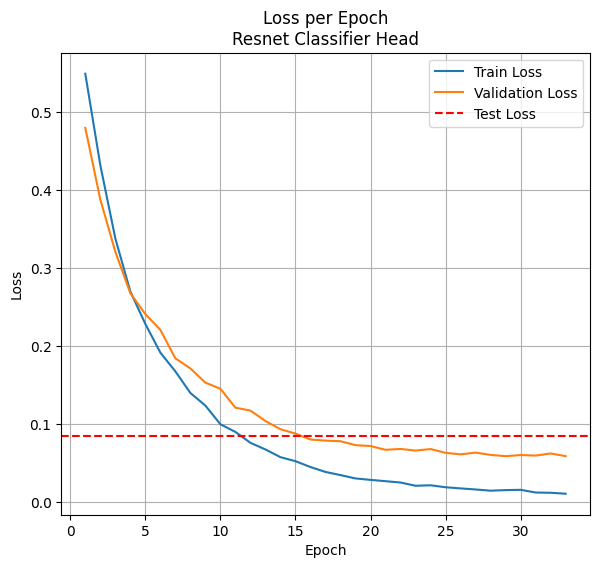

In [ ]:
epochs_range = range(1, epoch + 1)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.axhline(test_loss, linestyle='--', color='red', label='Test Loss')
plt.title('Loss per Epoch\nResnet Classifier Head')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
torch.save(classifier_model.state_dict(), "Models/autoencoder_resnet.pth")

# ResNet Import

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = Autoencoder(latent_dim=128)
model.load_state_dict(torch.load("Models/autoencoder.pth"))
model.eval()

encoder = model.encoder

classifier_model = TumorClassifierRes(encoder, latent_dim=128).to(device)

classifier_model.load_state_dict(torch.load("Models/autoencoder_resnet.pth"))

classifier_model.eval()

Using device: cuda


TumorClassifierRes(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=131072, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): ResNetBlock1D(
      (block): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Linear(in_features

# Conformal Prediction


Significance Level (alpha): 0.05
Desired Coverage: 0.95
Number of calibration scores: 302
Quantile index: 287
Calculated q_hat (threshold): 0.1251

Conformal Prediction Results:
Total samples in final test set: 453
Empirical Coverage: 0.9558 (Expected: >= 0.95)
Average Prediction Set Size: 0.9779


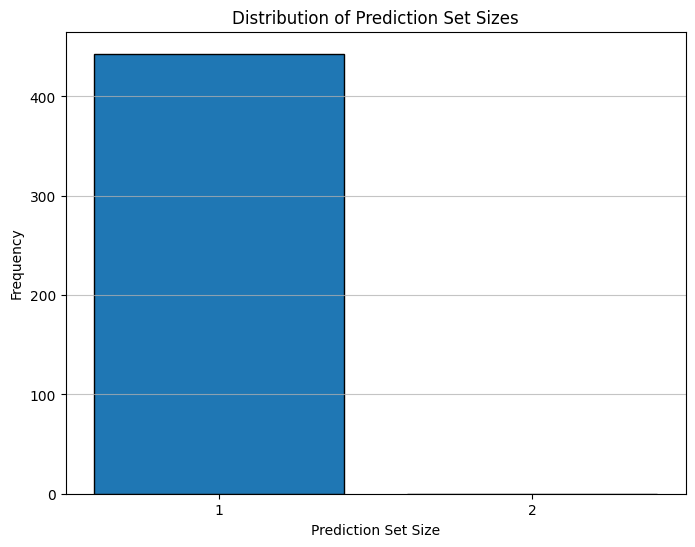

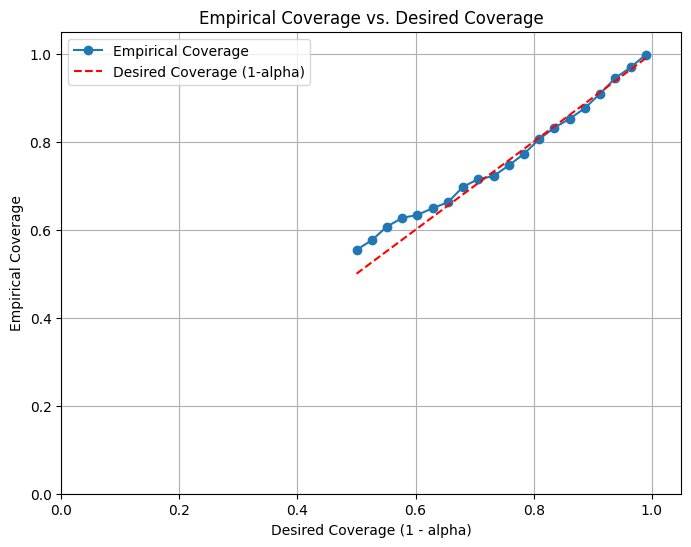

In [13]:
conformal_prediction(classifier_model, 0.05, calibration_loader, test_loader, device)

# SHAP

In [ ]:
model = Autoencoder(latent_dim=128)
model.load_state_dict(torch.load("Models/autoencoder.pth"))
model.eval()

encoder = model.encoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classifier_model = TumorClassifierRes(encoder, latent_dim=128).to(device)

# Load the classifier model state dictionary, mapping CUDA tensors to CPU if necessary
classifier_model.load_state_dict(torch.load("Models/autoencoder_resnet.pth", map_location=torch.device('cpu')))
classifier_model.eval()

TumorClassifierRes(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=131072, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): ResNetBlock1D(
      (block): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Linear(in_features

Background data shape for SHAP: torch.Size([302, 3, 256, 256])

Explaining 5 random images per class...

--- Explaining images for Class: 'meningioma' (Label: 0) ---
Processing image 1/5 for class 'meningioma' (Test Dataset Index: 112)...
  Model raw logit prediction: -5.3672
  Model predicted probability: 0.0046
  Model predicted label: 0 ('meningioma')


<Figure size 800x600 with 0 Axes>

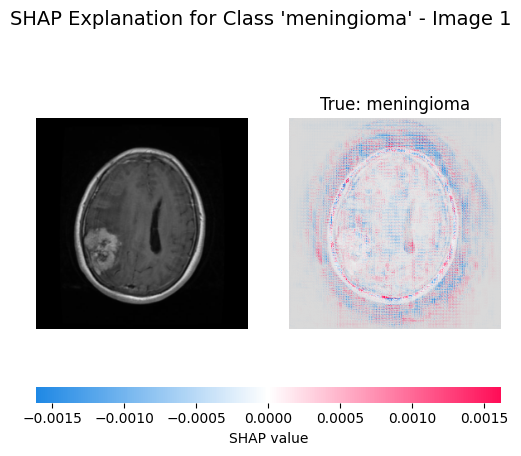

Processing image 2/5 for class 'meningioma' (Test Dataset Index: 143)...
  Model raw logit prediction: -4.6597
  Model predicted probability: 0.0094
  Model predicted label: 0 ('meningioma')


<Figure size 800x600 with 0 Axes>

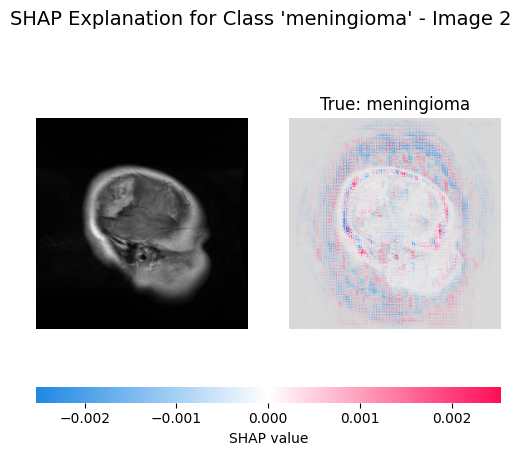

Processing image 3/5 for class 'meningioma' (Test Dataset Index: 51)...
  Model raw logit prediction: -4.6183
  Model predicted probability: 0.0098
  Model predicted label: 0 ('meningioma')


<Figure size 800x600 with 0 Axes>

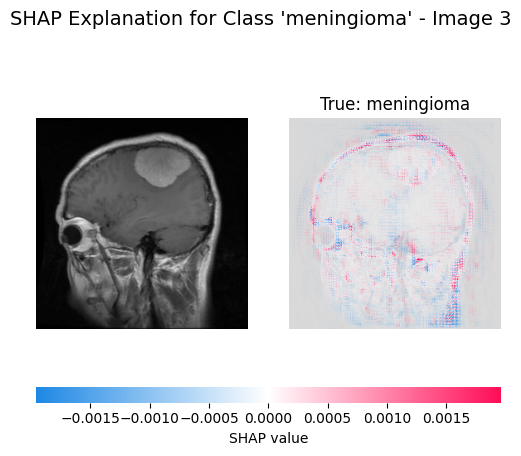

Processing image 4/5 for class 'meningioma' (Test Dataset Index: 79)...
  Model raw logit prediction: -4.8293
  Model predicted probability: 0.0079
  Model predicted label: 0 ('meningioma')


<Figure size 800x600 with 0 Axes>

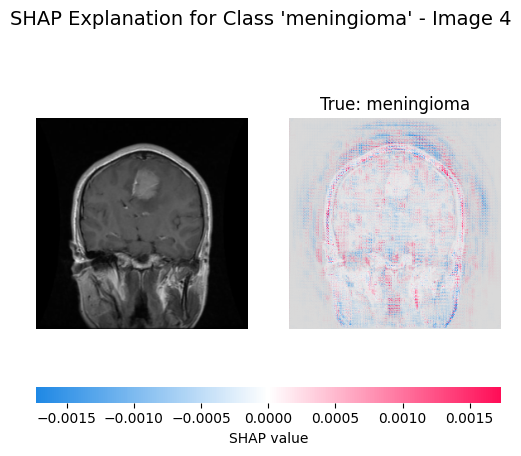

Processing image 5/5 for class 'meningioma' (Test Dataset Index: 201)...
  Model raw logit prediction: 4.0200
  Model predicted probability: 0.9824
  Model predicted label: 1 ('notumor')


<Figure size 800x600 with 0 Axes>

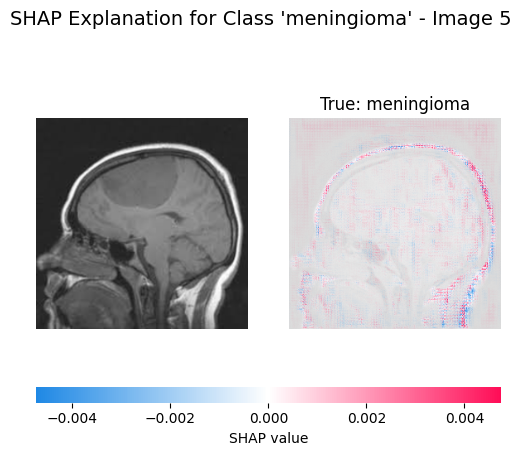


--- Explaining images for Class: 'notumor' (Label: 1) ---
Processing image 1/5 for class 'notumor' (Test Dataset Index: 293)...
  Model raw logit prediction: 4.1633
  Model predicted probability: 0.9847
  Model predicted label: 1 ('notumor')


<Figure size 800x600 with 0 Axes>

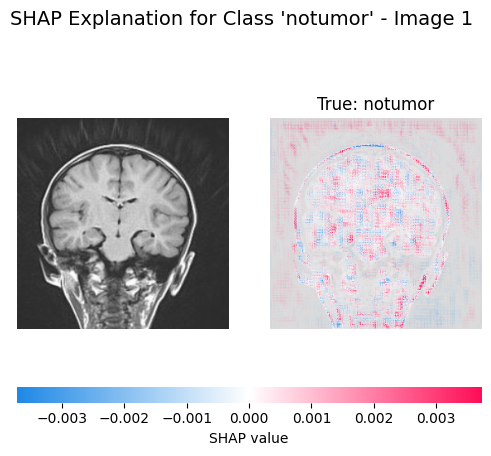

Processing image 2/5 for class 'notumor' (Test Dataset Index: 175)...
  Model raw logit prediction: 6.0423
  Model predicted probability: 0.9976
  Model predicted label: 1 ('notumor')


<Figure size 800x600 with 0 Axes>

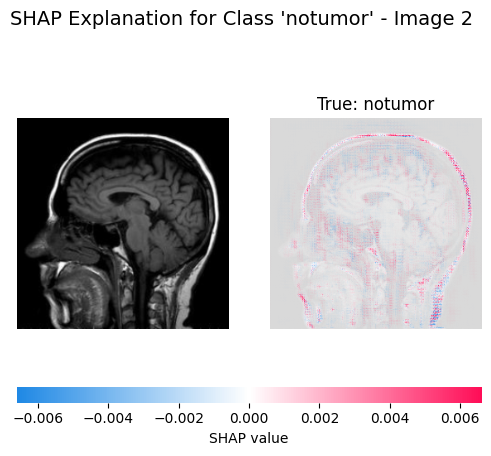

Processing image 3/5 for class 'notumor' (Test Dataset Index: 287)...
  Model raw logit prediction: 3.8819
  Model predicted probability: 0.9798
  Model predicted label: 1 ('notumor')


<Figure size 800x600 with 0 Axes>

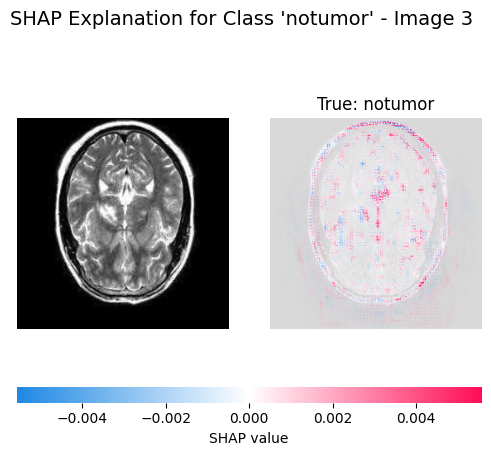

Processing image 4/5 for class 'notumor' (Test Dataset Index: 193)...
  Model raw logit prediction: 5.1415
  Model predicted probability: 0.9942
  Model predicted label: 1 ('notumor')


<Figure size 800x600 with 0 Axes>

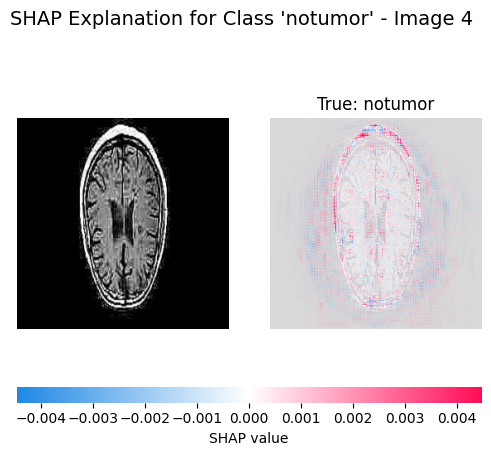

Processing image 5/5 for class 'notumor' (Test Dataset Index: 108)...
  Model raw logit prediction: 5.1259
  Model predicted probability: 0.9941
  Model predicted label: 1 ('notumor')


<Figure size 800x600 with 0 Axes>

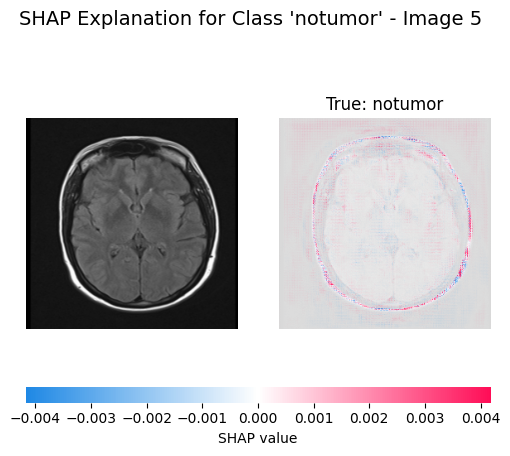


All SHAP explanation processes complete for selected images.


In [ ]:
background_data = []
num_background_batches = 5
for i, (images, _) in enumerate(calibration_loader):
    if i >= num_background_batches:
        break
    background_data.append(images)
background = torch.cat(background_data, dim=0).to(device)
print(f"Background data shape for SHAP: {background.shape}")

# Initialize SHAP GradientExplainer
explainer = shap.GradientExplainer(classifier_model, background)

# Select and Explain images per class
num_images_per_class = 5
class_names = calibration_dataset.dataset.classes # Get class names

# Separate indices by class
class_indices = {i: [] for i in range(len(class_names))}
for idx, (_, label) in enumerate(calibration_dataset):
    class_indices[label].append(idx)

print(f"\nExplaining {num_images_per_class} random images per class...")

for class_label in sorted(class_indices.keys()):
    class_name = class_names[class_label]
    print(f"\n--- Explaining images for Class: '{class_name}' (Label: {class_label}) ---")

    # Randomly select N images from the indices
    selected_indices = random.sample(class_indices[class_label], min(num_images_per_class, len(class_indices[class_label])))

    for i, idx in enumerate(selected_indices):
        print(f"Processing image {i+1}/{num_images_per_class} for class '{class_name}' (Test Dataset Index: {idx})...")

        # Get the image and its true label
        image_to_explain_tensor, true_label = calibration_dataset[idx]
        image_to_explain = image_to_explain_tensor.unsqueeze(0).to(device)

        # Get the model's prediction
        with torch.no_grad():
            logit_prediction = classifier_model(image_to_explain).item()
            predicted_probability = torch.sigmoid(torch.tensor(logit_prediction)).item()
            predicted_label = 1 if predicted_probability >= 0.5 else 0

        print(f"  Model raw logit prediction: {logit_prediction:.4f}")
        print(f"  Model predicted probability: {predicted_probability:.4f}")
        print(f"  Model predicted label: {predicted_label} ('{class_names[predicted_label]}')")

        # Compute SHAP values
        shap_values_raw = explainer.shap_values(image_to_explain)

        shap_values_for_plot = shap_values_raw[0][0]

        # Unnormalize the image for plotting
        img_unnormalized = (image_to_explain_tensor.cpu().numpy() * 0.5) + 0.5
        img_unnormalized = np.clip(img_unnormalized, 0, 1)
        img_unnormalized = np.transpose(img_unnormalized, (1, 2, 0))

        # Display SHAP heatmap
        plt.figure(figsize=(8, 6))
        shap.image_plot(shap_values_for_plot, img_unnormalized,
                        labels=[f"True: {class_names[true_label]}", f"Predicted: {class_names[predicted_label]} (P={predicted_probability:.2f})"],
                        show=False)
        plt.suptitle(f"SHAP Explanation for Class '{class_name}' - Image {i+1}", fontsize=14)
        plt.show()

print("\nAll SHAP explanation processes complete for selected images.")